# House Prices – Advanced Regression Techniques

This notebook walks through a complete regression workflow on the Ames Housing dataset:
exploratory analysis, preprocessing, feature engineering, model training, and evaluation.

**Target variable:** `SalePrice` (continuous house sale price in USD)

## 0. Setup & Data Loading

In [18]:
# Core data manipulation and visualization libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, modeling, and evaluation utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Consistent plot styling across the notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [19]:
# Load training data; Id is an identifier and will be dropped before modeling
df = pd.read_csv('train.csv')
df = df.drop(columns=['Id'])

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset shape: 1460 rows × 80 columns


---
## 1. Exploratory Data Analysis (EDA)

Understand the structure, data types, and distribution of the target before any transformations.

In [20]:
# Shape confirms sample size and feature count
print('Shape:', df.shape)

# Data types help separate numerical vs categorical preprocessing paths
print('\nData types:')
print(df.dtypes.value_counts())

# Basic statistics for numerical columns (count, mean, std, quartiles)
df.describe().T.head(10)

Shape: (1460, 80)

Data types:
object     43
int64      34
float64     3
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.0,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.0,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.0,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.0,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.0,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.0,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.0,0.0,0.00,1474.0


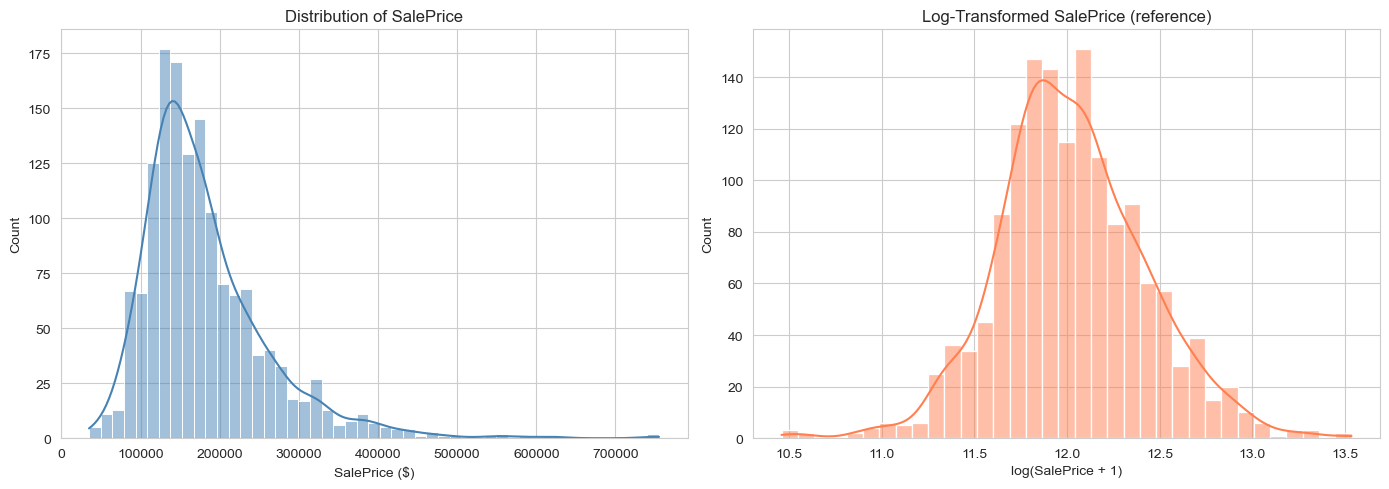

SalePrice — mean: $180,921 | median: $163,000


In [21]:
# SalePrice is right-skewed; log-transform is common but we model raw prices here
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of SalePrice')
axes[0].set_xlabel('SalePrice ($)')

# Q-Q style view via KDE on log scale to assess skewness
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log-Transformed SalePrice (reference)')
axes[1].set_xlabel('log(SalePrice + 1)')

plt.tight_layout()
plt.show()

print(f"SalePrice — mean: ${df['SalePrice'].mean():,.0f} | median: ${df['SalePrice'].median():,.0f}")

---
## 2. Data Preprocessing & Cleaning

Handle missing values and remove extreme outliers that can distort linear models.

In [22]:
# Work on a copy so the original frame stays untouched for reference
data = df.copy()

# In this dataset, NA often means "feature not present" (e.g., no pool, no alley)
none_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
for col in none_cols:
    if col in data.columns:
        data[col] = data[col].fillna('None')

# LotFrontage missingness is neighborhood-dependent; median is a robust default
if data['LotFrontage'].isnull().any():
    data['LotFrontage'] = data.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())

# Remaining numeric NaNs → median (robust to outliers)
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

# Remaining categorical NaNs → mode, or 'None' if no mode exists
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if data[col].isnull().any():
        mode_val = data[col].mode()
        fill_val = mode_val.iloc[0] if len(mode_val) > 0 else 'None'
        data[col] = data[col].fillna(fill_val)

print('Missing values after imputation:', data.isnull().sum().sum())

Missing values after imputation: 0


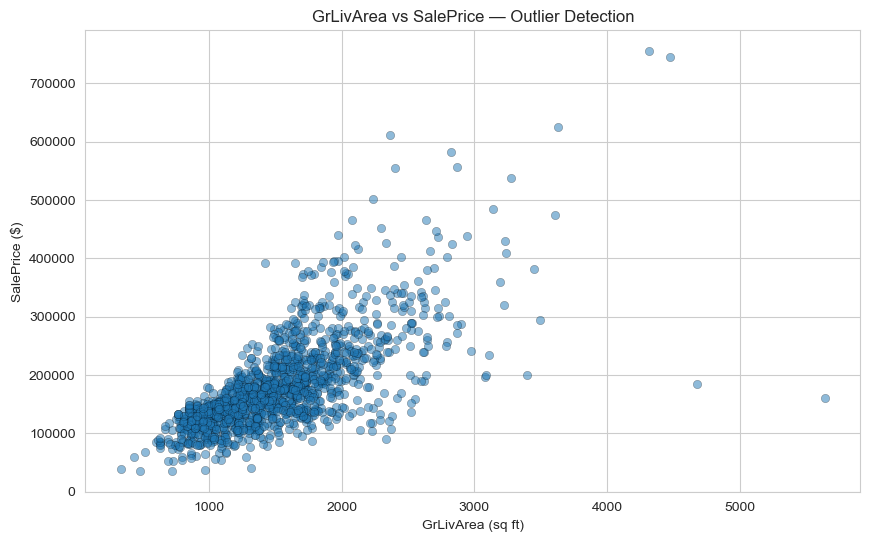

Outliers flagged for removal: 2
Shape after outlier removal: (1458, 80)


In [23]:
# Visual outlier check: large living area with unusually low price is a known data error
plt.figure(figsize=(10, 6))
plt.scatter(data['GrLivArea'], data['SalePrice'], alpha=0.5, edgecolors='k', linewidth=0.3)
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('GrLivArea vs SalePrice — Outlier Detection')
plt.show()

# Remove classic Ames outliers: very large homes sold at very low prices
outlier_mask = (data['GrLivArea'] > 4000) & (data['SalePrice'] < 300000)
print(f'Outliers flagged for removal: {outlier_mask.sum()}')

data = data.loc[~outlier_mask].reset_index(drop=True)
print(f'Shape after outlier removal: {data.shape}')

---
## 3. Feature Engineering & Encoding

Create intuitive derived features and encode categoricals for modeling.

In [24]:
# TotalSF: overall interior square footage is a strong price driver
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

# HouseAge: newer or recently remodeled homes tend to command higher prices
data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']

data[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF', 'HouseAge', 'RemodAge']].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF,HouseAge,RemodAge
0,856,856,854,2566,5,5
1,1262,1262,0,2524,31,31
2,920,920,866,2706,7,6
3,756,961,756,2473,91,36
4,1145,1145,1053,3343,8,8


In [25]:
# Ordinal mappings preserve natural order (e.g., Po < Fa < TA < Gd < Ex)
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    if col in data.columns:
        data[col] = data[col].map(quality_map).fillna(0).astype(int)

# Additional ordinal features with domain-specific order
ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'MLQ': 5, 'ALQ': 6, 'GLQ': 7},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'MLQ': 5, 'ALQ': 6, 'GLQ': 7},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'Street': {'Grvl': 1, 'Pave': 2},
    'Utilities': {'ELO': 1, 'NoSeWa': 2, 'NoSewr': 3, 'AllPub': 4},
    'CentralAir': {'N': 0, 'Y': 1},
    'LandContour': {'Low': 1, 'Bnk': 2, 'HLS': 3, 'Lvl': 4},
}

for col, mapping in ordinal_maps.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)
        # Fallback label encoding for any unmapped categories
        if data[col].isnull().any():
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col].astype(str))

# Remaining object columns are nominal → one-hot encode with drop_first to avoid dummy trap
nominal_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f'Nominal columns to one-hot encode: {len(nominal_cols)}')

data = pd.get_dummies(data, columns=nominal_cols, drop_first=True)
print(f'Shape after encoding: {data.shape}')

Nominal columns to one-hot encode: 21
Shape after encoding: (1458, 206)


---
## 4. Feature Selection & Correlation Analysis

Identify features most related to `SalePrice` and remove redundant predictors.

TotalSF              0.832877
OverallQual          0.795774
GrLivArea            0.734968
ExterQual            0.686756
KitchenQual          0.662236
                       ...   
Condition2_RRAe      0.002989
Foundation_Wood      0.002705
RoofStyle_Mansard   -0.000319
RoofMatl_Metal      -0.000308
BsmtFinType2        -0.000025
Length: 205, dtype: float64
['TotalSF', 'OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'TotalBsmtSF', 'GarageCars', '1stFlrSF', 'GarageArea', 'BsmtQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'HouseAge', 'YearBuilt', 'FireplaceQu', 'RemodAge', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea']


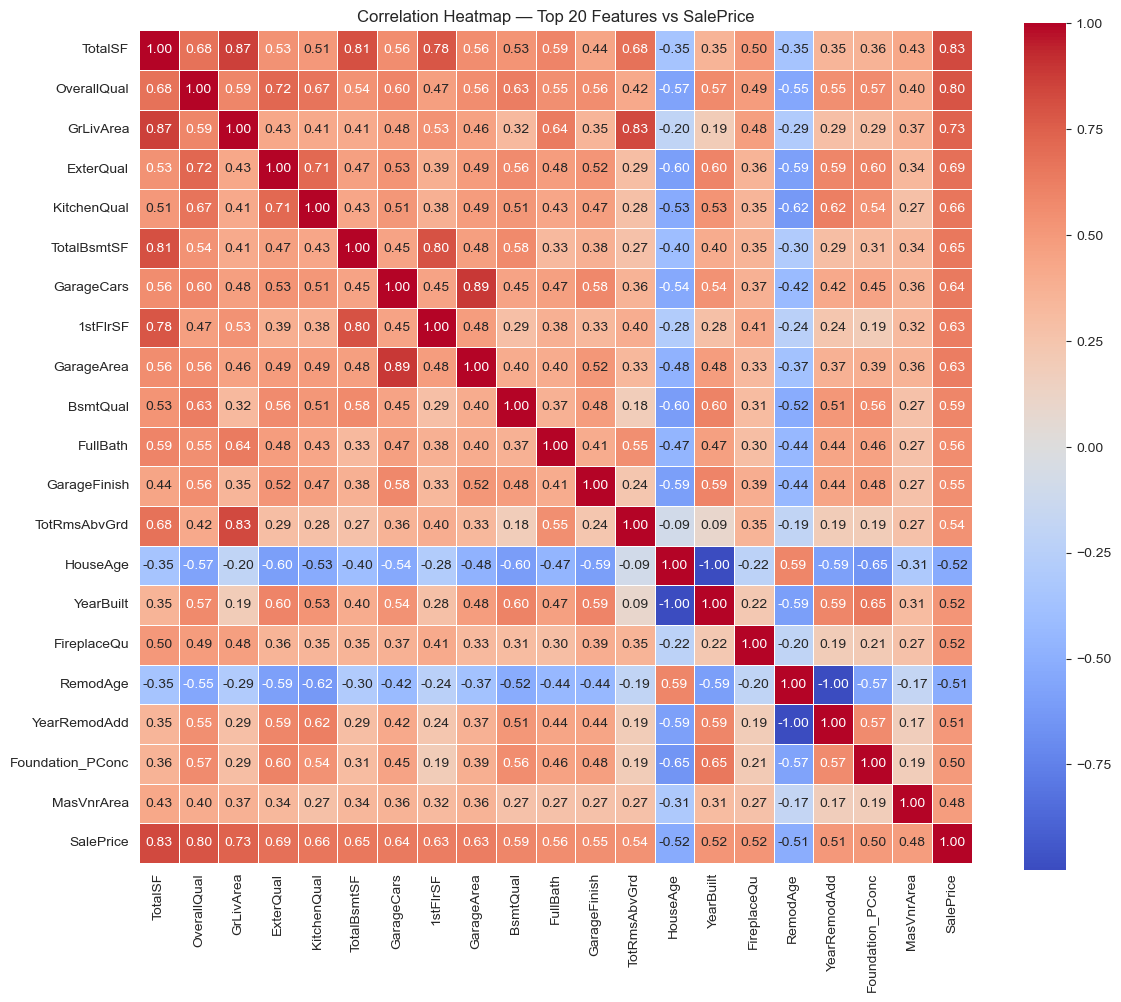

In [26]:
# Separate target from feature matrix
y = data['SalePrice']
X = data.drop(columns=['SalePrice'])

# Focus heatmap on numeric columns with highest |correlation| to SalePrice
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)
top_features = correlations.head(20).index.tolist()
print(correlations)
print(top_features)
corr_matrix = data[top_features + ['SalePrice']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top 20 Features vs SalePrice')
plt.tight_layout()
plt.show()

In [27]:
# Drop features with near-zero linear correlation to the target
low_corr_threshold = 0.05
low_corr_cols = correlations[correlations.abs() < low_corr_threshold].index.tolist()
X = X.drop(columns=low_corr_cols, errors='ignore')
print(f'Dropped {len(low_corr_cols)} low-correlation features (|r| < {low_corr_threshold})')

# Drop one feature from highly multicollinear pairs (|r| > 0.90) to stabilize linear models
corr_features = X.corr().abs()
upper_triangle = corr_features.where(
    np.triu(np.ones(corr_features.shape), k=1).astype(bool)
)

multicollinear_cols = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

# Prefer keeping TotalSF and dropping its components when redundant
preferred_drops = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageCars', 'TotRmsAbvGrd']
cols_to_drop = [col for col in preferred_drops if col in multicollinear_cols]
cols_to_drop += [col for col in multicollinear_cols if col not in cols_to_drop]

X = X.drop(columns=cols_to_drop, errors='ignore')
print(f'Dropped {len(cols_to_drop)} multicollinear features: {cols_to_drop}')
print(f'Final feature count: {X.shape[1]}')

Dropped 75 low-correlation features (|r| < 0.05)
Dropped 11 multicollinear features: ['GarageCond', 'PoolQC', 'HouseAge', 'RemodAge', 'RoofStyle_Hip', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'GarageType_None', 'MiscFeature_Shed', 'SaleCondition_Partial']
Final feature count: 119


---
## 5. Model Building (Regression)

Split data and train three linear models: baseline OLS, Ridge (L2), and Lasso (L1).

In [28]:
# 80/20 split with fixed seed for reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]} | Validation samples: {X_val.shape[0]}')

Training samples: 1166 | Validation samples: 292


In [29]:
def rmse(y_true, y_pred):
    """Root Mean Squared Error — standard regression metric (lower is better)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


# a) Linear Regression — unregularized baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# b) Ridge Regression — L2 penalty shrinks coefficients, handles multicollinearity
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# c) Lasso Regression — L1 penalty can drive some coefficients to exactly zero
lasso_model = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso_model.fit(X_train, y_train)

models = {
    'Linear Regression': lr_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
}

for name, model in models.items():
    train_score = rmse(y_train, model.predict(X_train))
    val_score = rmse(y_val, model.predict(X_val))
    print(f'{name:22s} | Train RMSE: ${train_score:,.0f} | Val RMSE: ${val_score:,.0f}')

Linear Regression      | Train RMSE: $22,564 | Val RMSE: $26,136
Ridge Regression       | Train RMSE: $22,661 | Val RMSE: $25,323
Lasso Regression       | Train RMSE: $22,564 | Val RMSE: $26,136


---
## 6. Model Evaluation, Tuning, and Comparison

Use cross-validation for robust error estimates and grid search to tune regularization strength (`alpha`).

In [30]:
# 5-fold CV on training data — negative MSE because sklearn maximizes scores
cv_folds = 5
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_folds,
        scoring='neg_root_mean_squared_error'
    )
    cv_results[name] = -scores
    print(f'{name:22s} | CV RMSE: ${cv_results[name].mean():,.0f} ± ${cv_results[name].std():,.0f}')

Linear Regression      | CV RMSE: $27,728 ± $1,814
Ridge Regression       | CV RMSE: $27,396 ± $1,350
Lasso Regression       | CV RMSE: $27,728 ± $1,814


In [31]:
# GridSearchCV to find optimal alpha for Ridge and Lasso
alpha_grid = np.logspace(-2, 3, 50)
param_grid = {'alpha': alpha_grid}

ridge_search = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=cv_folds,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

lasso_search = GridSearchCV(
    Lasso(random_state=42, max_iter=10000),
    param_grid,
    cv=cv_folds,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

print(f'Best Ridge alpha: {ridge_search.best_params_["alpha"]:.4f}')
print(f'Best Lasso alpha: {lasso_search.best_params_["alpha"]:.4f}')

# Retrain tuned models on full training set
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_

tuned_models = {
    'Linear Regression': lr_model,
    'Ridge Regression': best_ridge,
    'Lasso Regression': best_lasso,
}

Best Ridge alpha: 4.4984
Best Lasso alpha: 75.4312


In [32]:
# Summary table: train RMSE, validation RMSE, and mean CV RMSE
comparison_rows = []

for name, model in tuned_models.items():
    train_rmse = rmse(y_train, model.predict(X_train))
    val_rmse = rmse(y_val, model.predict(X_val))
    cv_rmse = cross_val_score(
        model, X_train, y_train,
        cv=cv_folds,
        scoring='neg_root_mean_squared_error'
    )
    comparison_rows.append({
        'Model': name,
        'Train RMSE': round(train_rmse, 2),
        'Validation RMSE': round(val_rmse, 2),
        'CV RMSE (mean)': round(-cv_rmse.mean(), 2),
        'CV RMSE (std)': round(cv_rmse.std(), 2),
    })

results_df = pd.DataFrame(comparison_rows).sort_values('Validation RMSE')
best_model = results_df.iloc[0]['Model']

print('=' * 60)
print('MODEL COMPARISON SUMMARY')
print('=' * 60)
display(results_df.style.highlight_min(subset=['Validation RMSE', 'CV RMSE (mean)'], color='lightgreen'))
print(f'\nBest-performing model (lowest Validation RMSE): {best_model}')

MODEL COMPARISON SUMMARY


,Model,Train RMSE,Validation RMSE,CV RMSE (mean),CV RMSE (std)
1,Ridge Regression,23061.250000,24618.150000,27251.490000,1370.870000
2,Lasso Regression,23168.640000,24769.310000,27249.950000,1564.030000
0,Linear Regression,22564.220000,26135.640000,27728.290000,1813.640000



Best-performing model (lowest Validation RMSE): Ridge Regression


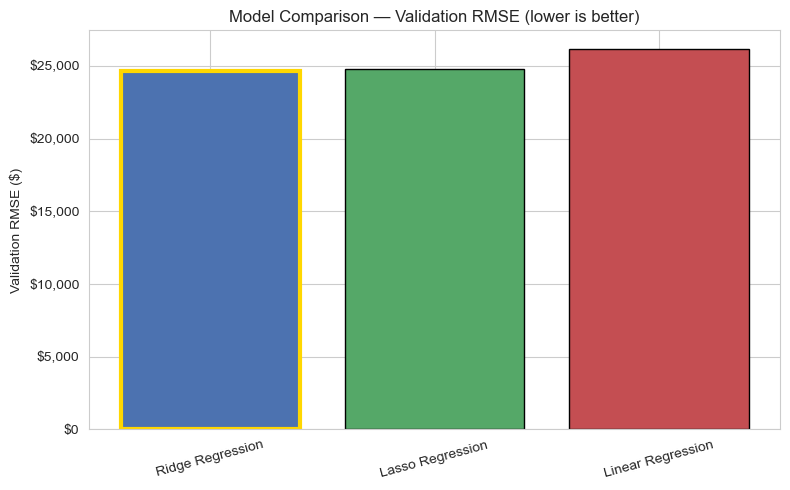

In [33]:
# Visual comparison of validation RMSE across models
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(results_df['Model'], results_df['Validation RMSE'], color=colors, edgecolor='black')

best_idx = results_df['Validation RMSE'].idxmin()
bars[results_df.index.get_loc(best_idx)].set_edgecolor('gold')
bars[results_df.index.get_loc(best_idx)].set_linewidth(3)

ax.set_ylabel('Validation RMSE ($)')
ax.set_title('Model Comparison — Validation RMSE (lower is better)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Key Takeaways

- **EDA** revealed a right-skewed `SalePrice` distribution, typical for housing markets.
- **Preprocessing** (median/mode imputation + outlier removal) improves linear model stability.
- **Feature engineering** (`TotalSF`, `HouseAge`) captures intuitive price drivers.
- **Regularized models** (Ridge/Lasso) often outperform plain linear regression when features are correlated.
- **Cross-validation + GridSearchCV** provide reliable RMSE estimates and tuned `alpha` values.